# Notebook 04 (v3): Land Value Decomposition — Hybrid Approach

## Summary of Findings So Far

We attempted hedonic subtraction (land-only model → site value, residual →
improvement value) using two approaches:
- **v1**: Included high-cardinality categorical location features → model
  memorized neighborhood improvement quality → site ratio ~100%
- **v2**: Constrained to continuous spatial features only → location still
  dominates predictions → site ratio ~100%

**Key insight**: In Cook County, spatial location explains so much of total
property value that a land-features-only model reconstructs nearly all of
the full AVM's predictions, leaving ~0 for improvements. This is a known
limitation of hedonic decomposition in markets where location is the
dominant value driver.

## This Notebook's Approach

1. **Primary decomposition**: Use the CCAO Assessor's own land/building
   assessed values (already in our data). These are produced by the
   Valuations department using established assessment methodology.
2. **Hedonic comparison**: Keep the constrained land model as a
   methodological reference to show WHY ML-based decomposition fails here.
3. **Validation**: Compare both approaches and discuss implications.

In [7]:
import pandas as pd
import numpy as np
import json
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", "{:.2f}".format)

In [8]:
assessment = pd.read_parquet("../data/processed/assessment_clean.parquet")

with open("../data/processed/feature_config.json") as f:
    config = json.load(f)

TARGET = config["target_col"]
CLASS_COL = config["class_col"]

# Load full AVM
lgb_full_model = lgb.Booster(model_file="../outputs/models/lgb_avm_model.txt")

print(f"Assessment data: {assessment.shape}")

Assessment data: (1100150, 199)


## 1. Extract CCAO Assessed Land/Building Values

In [9]:
# Find the CCAO's own land and building assessed value columns
meta_cols = sorted([c for c in assessment.columns if "meta" in c.lower()])
land_bldg_cols = [c for c in meta_cols if "_land" in c or "_bldg" in c]
print("Available CCAO land/building columns:")
for col in land_bldg_cols:
    n = assessment[col].notna().sum()
    print(f"  {col}: {n:,} non-null ({100*n/len(assessment):.1f}%)")

Available CCAO land/building columns:
  meta_1yr_pri_board_bldg: 1,099,480 non-null (99.9%)
  meta_1yr_pri_board_land: 1,099,480 non-null (99.9%)
  meta_2yr_pri_board_bldg: 1,097,970 non-null (99.8%)
  meta_2yr_pri_board_land: 1,097,970 non-null (99.8%)
  meta_board_bldg: 166,891 non-null (15.2%)
  meta_board_land: 166,891 non-null (15.2%)
  meta_certified_bldg: 1,100,150 non-null (100.0%)
  meta_certified_land: 1,100,150 non-null (100.0%)
  meta_mailed_bldg: 1,100,150 non-null (100.0%)
  meta_mailed_land: 1,100,150 non-null (100.0%)
  meta_pin_num_landlines: 1,100,145 non-null (100.0%)


In [10]:
# Select the best available land and building columns
# Priority: board (final) > certified > mailed > prior year
LAND_COL = None
BLDG_COL = None

for prefix in ["meta_board", "meta_certified", "meta_mailed",
               "meta_1yr_pri_board", "meta_2yr_pri_board"]:
    lc = f"{prefix}_land"
    bc = f"{prefix}_bldg"
    if lc in assessment.columns and bc in assessment.columns:
        coverage = assessment[lc].notna().mean()
        if coverage > 0.3:
            LAND_COL = lc
            BLDG_COL = bc
            print(f"Selected: {LAND_COL} / {BLDG_COL} (coverage: {coverage:.1%})")
            break

if LAND_COL is None:
    raise ValueError("No CCAO land/building columns found with sufficient coverage!")

Selected: meta_certified_land / meta_certified_bldg (coverage: 100.0%)


In [11]:
# Convert assessed values to estimated market values
# In Cook County: Assessed Value = Market Value x Assessment Level
# Residential classes are assessed at 10% of market value

ASSESSMENT_LEVELS = {
    "200": 0.10, "202": 0.10, "203": 0.10, "204": 0.10, "205": 0.10,
    "206": 0.10, "207": 0.10, "208": 0.10, "209": 0.10, "210": 0.10,
    "211": 0.10, "212": 0.10, "234": 0.10, "278": 0.10, "295": 0.10,
}

assessment["assessment_level"] = (
    assessment[CLASS_COL].astype(str).map(ASSESSMENT_LEVELS).fillna(0.10)
)

# Market value = Assessed value / assessment level
assessment["ccao_land_mv"] = assessment[LAND_COL] / assessment["assessment_level"]
assessment["ccao_bldg_mv"] = assessment[BLDG_COL] / assessment["assessment_level"]
assessment["ccao_total_mv"] = assessment["ccao_land_mv"] + assessment["ccao_bldg_mv"]

# Site-to-total ratio
assessment["ccao_site_ratio"] = (
    assessment["ccao_land_mv"] / assessment["ccao_total_mv"].replace(0, np.nan)
)

print("=== CCAO Market Value Decomposition ===")
print(f"Land MV:   median=${assessment['ccao_land_mv'].median():,.0f}, "
      f"mean=${assessment['ccao_land_mv'].mean():,.0f}")
print(f"Bldg MV:   median=${assessment['ccao_bldg_mv'].median():,.0f}, "
      f"mean=${assessment['ccao_bldg_mv'].mean():,.0f}")
print(f"Total MV:  median=${assessment['ccao_total_mv'].median():,.0f}")
print(f"Site ratio: median={assessment['ccao_site_ratio'].median():.2%}, "
      f"mean={assessment['ccao_site_ratio'].mean():.2%}")

=== CCAO Market Value Decomposition ===
Land MV:   median=$56,390, mean=$85,124
Bldg MV:   median=$220,000, mean=$275,158
Total MV:  median=$286,090
Site ratio: median=20.81%, mean=23.00%


## 2. Predict Total Market Values with Full AVM

In [12]:
# Use our trained AVM for total value (more accurate than CCAO assessed)
full_feats = lgb_full_model.feature_name()
full_feats_available = [c for c in full_feats if c in assessment.columns]

# Categorical columns in the exact order stored during training
# (must align with lgb_full_model.pandas_categorical)
_CAT_COLS_ORDERED = [
    c for c in full_feats if c in [
        'char_air', 'char_apts', 'char_attic_fnsh', 'char_attic_type',
        'char_bsmt', 'char_bsmt_fin', 'char_ext_wall', 'char_gar1_att',
        'char_gar1_cnst', 'char_gar1_size', 'char_heat', 'char_porch',
        'char_roof_cnst', 'char_tp_dsgn', 'char_type_resd',
        'loc_census_tract_geoid', 'loc_school_elementary_district_geoid',
        'loc_school_secondary_district_geoid', 'loc_tax_municipality_name',
        'prox_nearest_road_arterial_surface_type',
        'prox_nearest_road_collector_surface_type',
        'prox_nearest_road_highway_surface_type',
        'time_sale_quarter_of_year',
    ]
]

assess_copy = assessment.copy()
for col, cats in zip(_CAT_COLS_ORDERED, lgb_full_model.pandas_categorical):
    if col in assess_copy.columns:
        assess_copy[col] = pd.Categorical(assess_copy[col], categories=cats)

assessment["pred_total_value"] = lgb_full_model.predict(
    assess_copy[full_feats_available]
)

print(f"AVM predicted total value: median=${assessment['pred_total_value'].median():,.0f}")

/var/folders/ks/kb5pst5x5t9_1l4qvp48_dnw0000gn/T/ipykernel_27968/3632541776.py:25: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  assess_copy[col] = pd.Categorical(assess_copy[col], categories=cats)
/var/folders/ks/kb5pst5x5t9_1l4qvp48_dnw0000gn/T/ipykernel_27968/3632541776.py:25: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  assess_copy[col] = pd.Categorical(assess_copy[col], categories=cats)


AVM predicted total value: median=$316,806


## 3. Apply CCAO Land Ratios to AVM-Predicted Total Values

Strategy: Use the CCAO's land-to-total *ratio* (which reflects their
domain expertise on the land/improvement split) and apply it to our
AVM's *total value prediction* (which is more accurate than raw
assessed values for current market conditions).

In [13]:
# Decomposition: AVM total x CCAO ratio
assessment["pred_site_value_adj"] = (
    assessment["pred_total_value"] * assessment["ccao_site_ratio"]
)
assessment["pred_improvement_value"] = (
    assessment["pred_total_value"] * (1 - assessment["ccao_site_ratio"])
)

# Handle edge cases
assessment["pred_site_value_adj"] = assessment["pred_site_value_adj"].clip(lower=0)
assessment["pred_improvement_value"] = assessment["pred_improvement_value"].clip(lower=0)

assessment["site_value_ratio"] = assessment["ccao_site_ratio"].copy()

print("=== Final Decomposition (AVM total x CCAO ratio) ===")
print(f"\nSite Value:        median=${assessment['pred_site_value_adj'].median():,.0f}")
print(f"Improvement Value: median=${assessment['pred_improvement_value'].median():,.0f}")
print(f"Total Value:       median=${assessment['pred_total_value'].median():,.0f}")
print(f"Site Ratio:        median={assessment['site_value_ratio'].median():.2%}")

=== Final Decomposition (AVM total x CCAO ratio) ===

Site Value:        median=$64,682
Improvement Value: median=$242,997
Total Value:       median=$316,806
Site Ratio:        median=20.81%


## 4. Why Hedonic Subtraction Failed — Methodological Discussion

In [14]:
# Load the constrained hedonic model for comparison
hedonic_model_path = "../outputs/models/lgb_land_model_v2.txt"
if Path(hedonic_model_path).exists():
    hedonic_model = lgb.Booster(model_file=hedonic_model_path)
    hedonic_feats = [c for c in hedonic_model.feature_name() if c in assessment.columns]
    
    assessment["hedonic_site_value"] = hedonic_model.predict(assessment[hedonic_feats])
    assessment["hedonic_site_ratio"] = (
        assessment["hedonic_site_value"] / 
        assessment["pred_total_value"].replace(0, np.nan)
    ).clip(0, 1)
    
    has_hedonic = True
else:
    has_hedonic = False
    print("No hedonic model found — skipping comparison.")

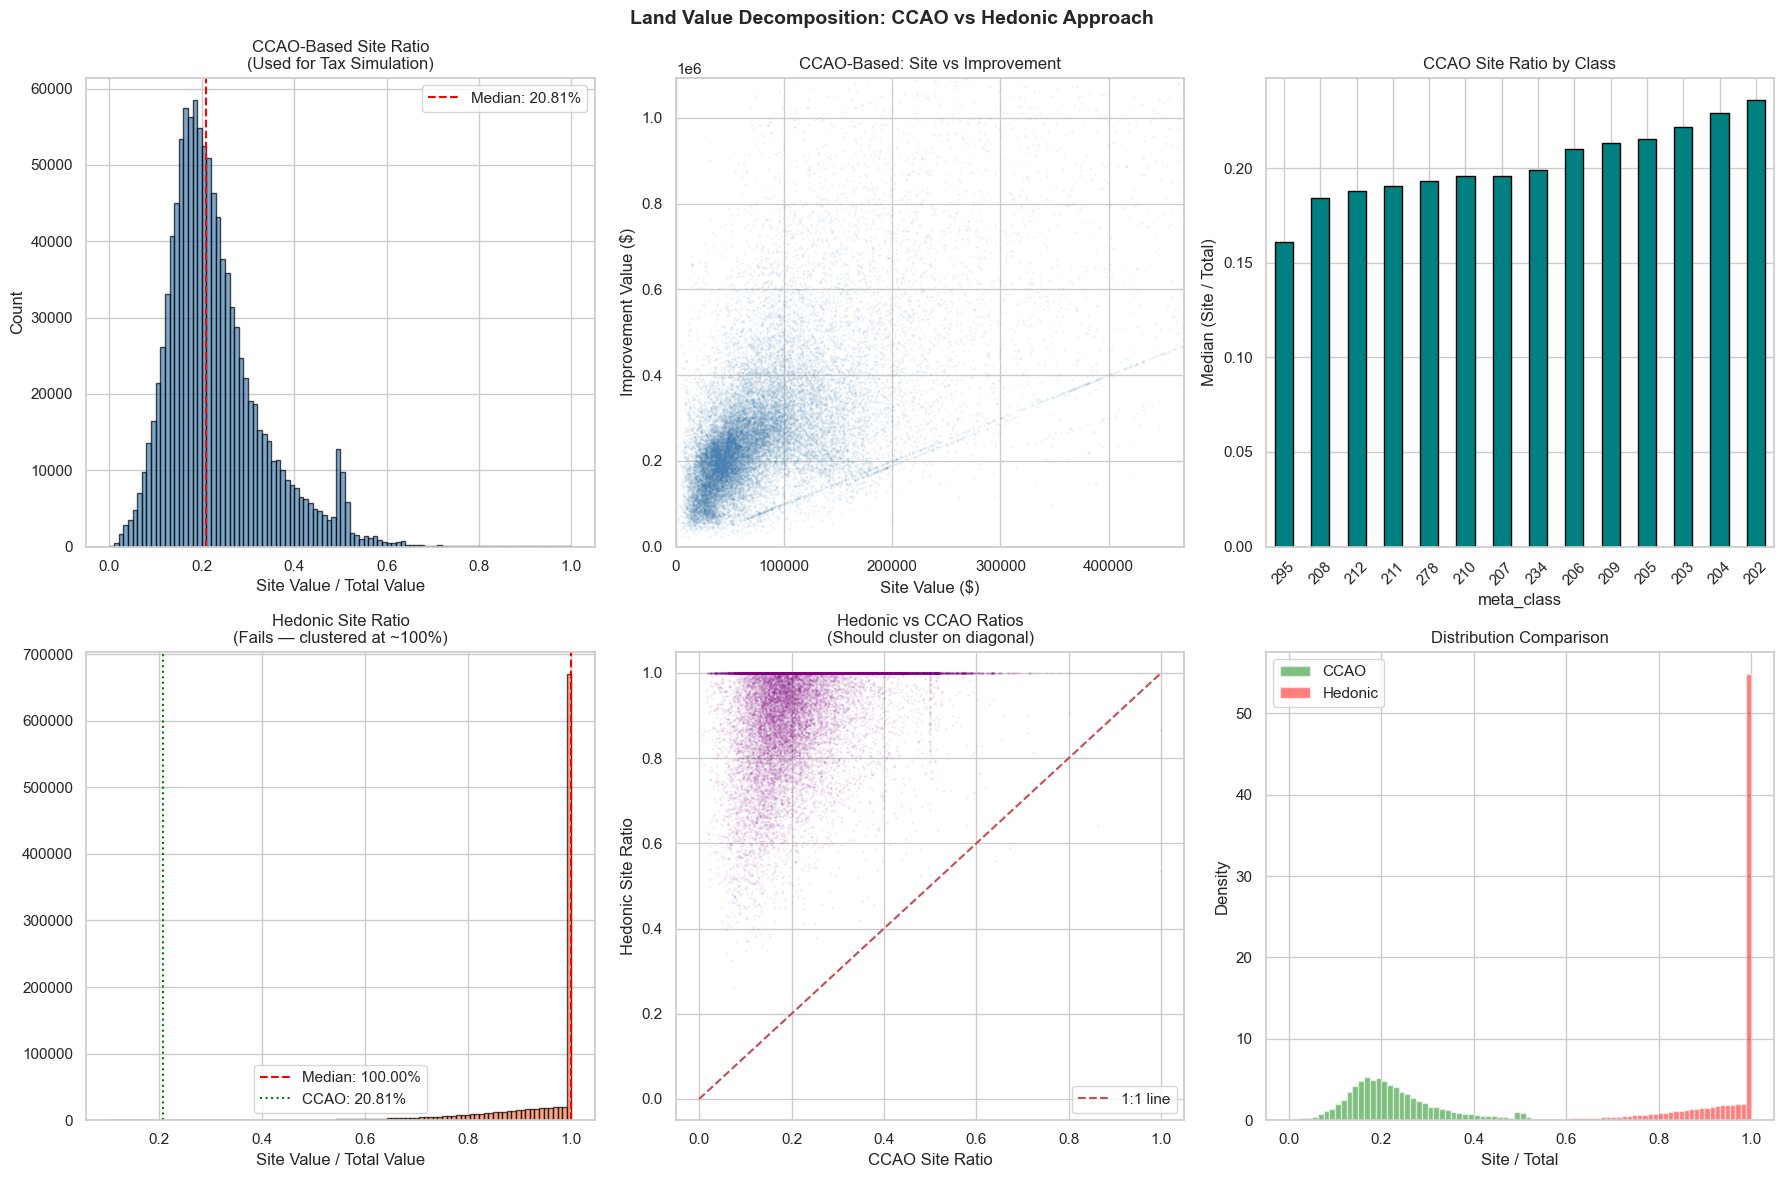

In [15]:
# === Comparison visualization ===
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Row 1: CCAO-based decomposition (what we're using)
ax = axes[0, 0]
valid = assessment["site_value_ratio"].dropna()
valid = valid[(valid >= 0) & (valid <= 1)]
ax.hist(valid, bins=100, color="steelblue", edgecolor="black", alpha=0.7)
ax.axvline(valid.median(), color="red", linestyle="--",
           label=f"Median: {valid.median():.2%}")
ax.set_title("CCAO-Based Site Ratio\n(Used for Tax Simulation)")
ax.set_xlabel("Site Value / Total Value")
ax.set_ylabel("Count")
ax.legend()

ax = axes[0, 1]
sample = assessment.sample(min(30000, len(assessment)), random_state=42)
ax.scatter(sample["pred_site_value_adj"], sample["pred_improvement_value"],
           alpha=0.05, s=1, color="steelblue")
ax.set_xlabel("Site Value ($)")
ax.set_ylabel("Improvement Value ($)")
ax.set_title("CCAO-Based: Site vs Improvement")
ax.set_xlim(0, sample["pred_site_value_adj"].quantile(0.99))
ax.set_ylim(0, sample["pred_improvement_value"].quantile(0.99))

ax = axes[0, 2]
class_ratios = assessment.groupby(CLASS_COL)["site_value_ratio"].median().sort_values()
class_ratios.plot(kind="bar", ax=ax, color="teal", edgecolor="black")
ax.set_title("CCAO Site Ratio by Class")
ax.set_ylabel("Median (Site / Total)")
ax.tick_params(axis="x", rotation=45)

# Row 2: Hedonic comparison (showing why it fails)
if has_hedonic:
    ax = axes[1, 0]
    h_valid = assessment["hedonic_site_ratio"].dropna()
    ax.hist(h_valid, bins=100, color="coral", edgecolor="black", alpha=0.7)
    ax.axvline(h_valid.median(), color="red", linestyle="--",
               label=f"Median: {h_valid.median():.2%}")
    ax.axvline(valid.median(), color="green", linestyle=":",
               label=f"CCAO: {valid.median():.2%}")
    ax.set_title("Hedonic Site Ratio\n(Fails — clustered at ~100%)")
    ax.set_xlabel("Site Value / Total Value")
    ax.legend()
    
    ax = axes[1, 1]
    ax.scatter(sample["ccao_site_ratio"].values,
               assessment.loc[sample.index, "hedonic_site_ratio"].values,
               alpha=0.05, s=1, color="purple")
    ax.plot([0, 1], [0, 1], "r--", label="1:1 line")
    ax.set_xlabel("CCAO Site Ratio")
    ax.set_ylabel("Hedonic Site Ratio")
    ax.set_title("Hedonic vs CCAO Ratios\n(Should cluster on diagonal)")
    ax.legend()
    
    ax = axes[1, 2]
    ax.hist(valid, bins=80, alpha=0.5, label="CCAO", color="green", density=True)
    ax.hist(h_valid, bins=80, alpha=0.5, label="Hedonic", color="red", density=True)
    ax.set_title("Distribution Comparison")
    ax.set_xlabel("Site / Total")
    ax.set_ylabel("Density")
    ax.legend()
else:
    for ax in axes[1, :]:
        ax.text(0.5, 0.5, "Hedonic model not available",
                ha="center", va="center", transform=ax.transAxes)

plt.suptitle("Land Value Decomposition: CCAO vs Hedonic Approach",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/figures/04v3_decomposition_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Geographic Analysis of Land Ratios

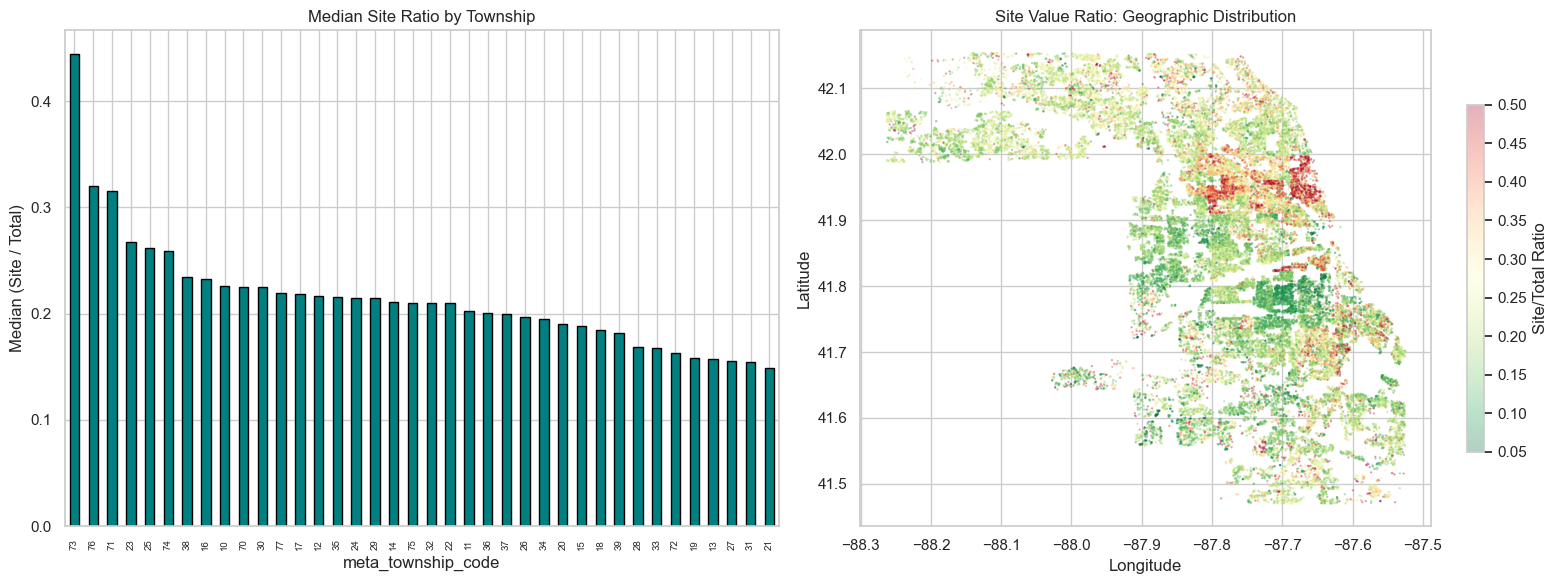

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# By township
if "meta_township_code" in assessment.columns:
    twp_ratios = (assessment.groupby("meta_township_code")["site_value_ratio"]
                  .median().sort_values(ascending=False))
    ax = axes[0]
    twp_ratios.plot(kind="bar", ax=ax, color="teal", edgecolor="black")
    ax.set_title("Median Site Ratio by Township")
    ax.set_ylabel("Median (Site / Total)")
    ax.tick_params(axis="x", rotation=90, labelsize=7)

# Spatial map of site ratios
ax = axes[1]
if "loc_latitude" in assessment.columns:
    geo_sample = assessment.dropna(subset=["loc_latitude", "loc_longitude",
                                            "site_value_ratio"]).sample(
        min(50000, len(assessment)), random_state=42
    )
    scatter = ax.scatter(
        geo_sample["loc_longitude"], geo_sample["loc_latitude"],
        c=geo_sample["site_value_ratio"], cmap="RdYlGn_r",
        s=0.5, alpha=0.3, vmin=0.05, vmax=0.5,
    )
    plt.colorbar(scatter, ax=ax, label="Site/Total Ratio", shrink=0.7)
    ax.set_title("Site Value Ratio: Geographic Distribution")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

plt.tight_layout()
plt.savefig("../outputs/figures/04v3_geographic_ratios.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Save Final Decomposition for Tax Simulation

In [17]:
# Tag homeowner classes
HOMEOWNER_CLASSES = ["202", "203", "204", "205", "206", "207", "208", "209"]
assessment["is_homeowner"] = assessment[CLASS_COL].astype(str).isin(HOMEOWNER_CLASSES)

output_cols = [
    "meta_pin", CLASS_COL, "meta_township_code", "meta_nbhd_code",
    "char_land_sf", "char_bldg_sf",
    "assessment_level", "is_homeowner",
    "pred_total_value", "pred_site_value_adj", "pred_improvement_value",
    "site_value_ratio",
    "ccao_land_mv", "ccao_bldg_mv", "ccao_total_mv", "ccao_site_ratio",
    LAND_COL, BLDG_COL,
]
# Add location for downstream analysis
for loc_col in ["loc_latitude", "loc_longitude"]:
    if loc_col in assessment.columns:
        output_cols.append(loc_col)

# Add hedonic comparison if available
if has_hedonic:
    output_cols += ["hedonic_site_value", "hedonic_site_ratio"]

output_cols = [c for c in output_cols if c in assessment.columns]
assessment[output_cols].to_parquet(
    "../data/processed/assessment_decomposed.parquet", index=False
)

# Save decomposition method metadata
decomp_meta = {
    "method": "CCAO assessed ratios applied to AVM total values",
    "land_av_column": LAND_COL,
    "bldg_av_column": BLDG_COL,
    "median_site_ratio": float(assessment["site_value_ratio"].median()),
    "mean_site_ratio": float(assessment["site_value_ratio"].mean()),
    "hedonic_attempted": True,
    "hedonic_result": "Failed — site ratio clustered at ~100% due to spatial dominance",
    "n_properties": len(assessment),
    "n_homeowners": int(assessment["is_homeowner"].sum()),
}
with open("../outputs/reports/decomposition_metadata.json", "w") as f:
    json.dump(decomp_meta, f, indent=2)

print("Saved: ../data/processed/assessment_decomposed.parquet")
print("Saved: ../outputs/reports/decomposition_metadata.json")
print(f"\nProperties: {len(assessment):,}")
print(f"Homeowners: {assessment['is_homeowner'].sum():,}")
print(f"Median site ratio: {assessment['site_value_ratio'].median():.2%}")

Saved: ../data/processed/assessment_decomposed.parquet
Saved: ../outputs/reports/decomposition_metadata.json

Properties: 1,100,150
Homeowners: 672,719
Median site ratio: 20.81%
